In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
!pip install --upgrade "glycowork @ git+https://github.com/BojarLab/glycowork.git@dev"
from glycowork.glycan_data.loader import glycomics_data_loader, df_glycan, build_custom_df, unwrap, df_species
from glycowork.network.biosynthesis import construct_network, find_diamonds, choose_path
from glycowork.network.biosynthesis import plot_network, export_network, highlight_network, trace_diamonds
from scipy.stats import ttest_rel, ttest_ind
from statsmodels.stats.multitest import multipletests
from collections import defaultdict
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

  Cloning https://github.com/BojarLab/glycowork.git (to revision dev) to /private/var/folders/lj/p78vp_151tb4lqfy3glspztm0000gn/T/pip-install-jyl4fats/glycowork_107819f98d1c4af19a076d5e218706fb
  Running command git clone --filter=blob:none --quiet https://github.com/BojarLab/glycowork.git /private/var/folders/lj/p78vp_151tb4lqfy3glspztm0000gn/T/pip-install-jyl4fats/glycowork_107819f98d1c4af19a076d5e218706fb
  Running command git checkout -b dev --track origin/dev
  Switched to a new branch 'dev'
  branch 'dev' set up to track 'origin/dev'.
  Resolved https://github.com/BojarLab/glycowork.git to commit c6cccb00e4750d28a9a10f86f25f988dc130947a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
#Function to extract reactions from diamond motifs in the network
def extract_diamond_reactions(net, diamonds):
    """
    Extract reactions from diamond motifs in the network.

    Parameters:
    net (networkx.Graph): The glycan biosynthesis network.
    diamonds (list of lists): List of diamond motifs, each containing nodes.

    Returns:
    list: A list of reactions associated with each diamond.
    """
    diamond_reactions = []
    for diamond in diamonds:
        reactions = []
        nodes = diamond

        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                if net.has_edge(nodes[i], nodes[j]):
                    reactions.append((nodes[i], nodes[j], net[nodes[i]][nodes[j]]['diffs'])) # Include start and end nodes with reaction
                elif net.has_edge(nodes[j], nodes[i]):
                    reactions.append((nodes[j], nodes[i], net[nodes[j]][nodes[i]]['diffs'])) # Include start and end nodes with reaction
        diamond_reactions.append(reactions)
    return diamond_reactions

# Function to display the reaction preferences based on intermediate abundance
def display_reaction_preferences(diamond_reactions, net):
    """
    Display the preferred order of reaction based on intermediate abundance.

    Parameters:
    diamond_reactions (list of tuples): Reactions extracted from diamonds.
    net (networkx.Graph): The glycan biosynthesis network containing node data.

    Returns:
    None
    """
    for idx, diamond_react in enumerate(diamond_reactions):
        start_node_groups = defaultdict(list)


        for start_node, end_node, diffs in diamond_react:
            abundance = net.nodes[end_node].get('abundance')
            start_node_groups[start_node].append((end_node, diffs, abundance))

        # Compare the abundance of intermediates and determine preference
        for start_node, reactions in start_node_groups.items():
            if len(reactions) == 2:
                intermediate1, diff1, abundance1 = reactions[0]
                intermediate2, diff2, abundance2 = reactions[1]

                # Ensure abundance values exist
                if abundance1 is not None and abundance2 is not None:
                    if abundance1 > abundance2:
                        preference = "forward"
                    elif abundance2 > abundance1:
                        preference = "reverse"
                    else:
                        preference = "no preference"

                    # Display the abundance along with the preference
                    print(f"Diamond at {start_node}:")
                    print(f"  {intermediate1} (abundance: {abundance1}) vs {intermediate2} (abundance: {abundance2})")
                    print(f"  Preferred Reaction: {preference} ({diff1} -> {diff2})\n")


# Load the data
df = glycomics_data_loader.human_skin_O_PMC5871710_BCC

# Construct the glycan network
net = construct_network(df.glycan.values.tolist(), abundances=df.iloc[:, 1].values.tolist())

# Find diamonds in the network
diamonds = find_diamonds(net, mode="abundance")

# Extract diamond reactions
diamond_list = [list(d.values()) for d in diamonds]
diamond_reactions = extract_diamond_reactions(net, diamond_list)


In [7]:
# Function to prepare reaction preferences data across all samples in a dataset
def collect_reaction_preferences_data(diamond_reactions, net, dataset, data_source):
    """
    Collect reaction preferences data across all samples in a dataset.

    Parameters:
    diamond_reactions (list of tuples): Reactions extracted from diamonds.
    net (networkx.Graph): The glycan biosynthesis network containing node data.
    dataset (DataFrame): The dataset with multiple samples (columns).
    data_source (str): Source of the data.

    Returns:
    DataFrame: Data for each sample in the dataset.
    """
    source_name = data_source.split('.')[-1]
    all_table_data = []

    for sample_idx in range(1, dataset.shape[1]):
        sample_name = dataset.columns[sample_idx]
        abundances = dataset.iloc[:, sample_idx].values.tolist()

        # Assign abundance values to nodes in the network
        for node, abundance in zip(net.nodes, abundances):
            net.nodes[node]['abundance'] = abundance

        # Collect reaction preferences based on abundance differences
        for diamond_react in diamond_reactions:
            start_node_groups = defaultdict(list)

            for start_node, end_node, diffs in diamond_react:
                abundance = net.nodes[end_node].get('abundance')
                start_node_groups[start_node].append((end_node, diffs, abundance))

            for start_node, reactions in start_node_groups.items():
                if len(reactions) == 2:
                    intermediate1, diff1, abundance1 = reactions[0]
                    intermediate2, diff2, abundance2 = reactions[1]

                    if abundance1 is not None and abundance2 is not None:
                        preference = "forward" if abundance1 > abundance2 else "reverse" if abundance2 > abundance1 else "no preference"

                        # Store the data
                        all_table_data.append({
                            'Start Point': start_node,
                            'Diff 1': diff1,
                            'Abundance 1': abundance1,
                            'Diff 2': diff2,
                            'Abundance 2': abundance2,
                            'Reaction Preference': preference,
                            'Sample Name': sample_name,
                            'Data Source': source_name
                        })

    return pd.DataFrame(all_table_data)
    # Collect data for each dataset
all_dataframes = []

for dataset_name in dir(glycomics_data_loader):
    if 'human_gastric' not in dataset_name:  # Include all datasets except 'human_gastric'
        try:
            dataset = getattr(glycomics_data_loader, dataset_name)

            # Check that dataset has the required structure
            if not hasattr(dataset, "glycan") or dataset.shape[1] < 2:
                print(f"Skipping dataset {dataset_name}: Missing required structure.")
                continue

            # If dataset contains 'time_series', transpose it
            if 'time_series_N_' in dataset_name:
                dataset = dataset.set_index('glycan').transpose().reset_index()
                dataset = dataset.rename(columns={'index': 'sample_name'})
                glycans = dataset.columns[1:].tolist()

            # If dataset contains '_N_', filter out rows with `{}` in glycans
            elif '_N_' in dataset_name:
                dataset = dataset[dataset['glycan'].notna() & ~dataset['glycan'].str.contains(r'\{|\}', regex=True, na=False)]
                glycans = dataset.glycan.values.tolist()

            # If dataset contains '_GSL_', add '1Cer' to each glycan
            elif '_GSL_' in dataset_name:
                dataset['glycan'] = dataset['glycan'] + "-1Cer"
                glycans = dataset.glycan.values.tolist()

            else:
                # Default glycans assignment for datasets not mentioned above
                glycans = dataset.glycan.values.tolist()

            # Construct the glycan network and diamonds only once per dataset
            abundances = dataset.iloc[:, 1].values.tolist()
            net = construct_network(glycans, abundances=abundances)
            diamonds = find_diamonds(net, mode="abundance")
            diamond_list = [list(d.values()) for d in diamonds]
            diamond_reactions = extract_diamond_reactions(net, diamond_list)

            # Collect data across all samples in this dataset
            df_table = collect_reaction_preferences_data(diamond_reactions, net, dataset, dataset_name)
            all_dataframes.append(df_table)

        except IndexError as e:
            print(f"Skipping dataset {dataset_name} due to an IndexError: {e}")
        except Exception as e:
            print(f"Skipping dataset {dataset_name} due to an unexpected error: {e}")

# Concatenate all collected DataFrames
df_combined_all_datasets = pd.concat(all_dataframes, ignore_index=True)


Skipping dataset human_leukemia_N_PMID34646384 due to an unexpected error: max() iterable argument is empty
Skipping dataset human_platelets_N_PMID36952551 due to an unexpected error: max() iterable argument is empty
Skipping dataset human_prostate_N_PMC8010466 due to an unexpected error: max() iterable argument is empty
Skipping dataset time_series_HMO_PMID22649065: Missing required structure.
Skipping dataset time_series_N_PMID32149347: Missing required structure.
Skipping dataset time_series_O_PMID32149347: Missing required structure.


In [9]:
# Filter and sort by 'Diff 1' and 'Diff 2'
df_combined_all_datasets = df_combined_all_datasets[df_combined_all_datasets['Reaction Preference'] != 'no preference']
df_combined_all_datasets = df_combined_all_datasets.sort_values(by=['Diff 1', 'Diff 2']).reset_index(drop=True)

# Apply Welch's T-test
results_welch = []
for (diff1, diff2), group in df_combined_all_datasets.groupby(['Diff 1', 'Diff 2']):
    if len(group) >= 2:
        group1 = group['Abundance 1'].dropna()
        group2 = group['Abundance 2'].dropna()

        if len(group1) > 1 and len(group2) > 1:
            t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
            mean_diff = group1.mean() - group2.mean()
            std_dev = (group1 - group2).std()
            error = std_dev / np.sqrt(len(group1))

            significance = '*** p < 0.001' if p_value < 0.001 else '** p < 0.01' if p_value < 0.01 else '* p < 0.05' if p_value < 0.05 else 'n.s., not significant'
            reaction_preference = 'reverse' if mean_diff > 0 else 'forward'

            results_welch.append({
                'Diff 1': diff1,
                'Diff 2': diff2,
                'Mean Difference (Abundance 1 - Abundance 2)': mean_diff,
                'Welch T-Statistic': t_stat,
                'Welch P-Value': p_value,
                'Significance': significance,
                'Reaction Preference': reaction_preference,
                'Error': error
            })

# Convert results to a DataFrame
results_welch_df = pd.DataFrame(results_welch)


/Applications/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


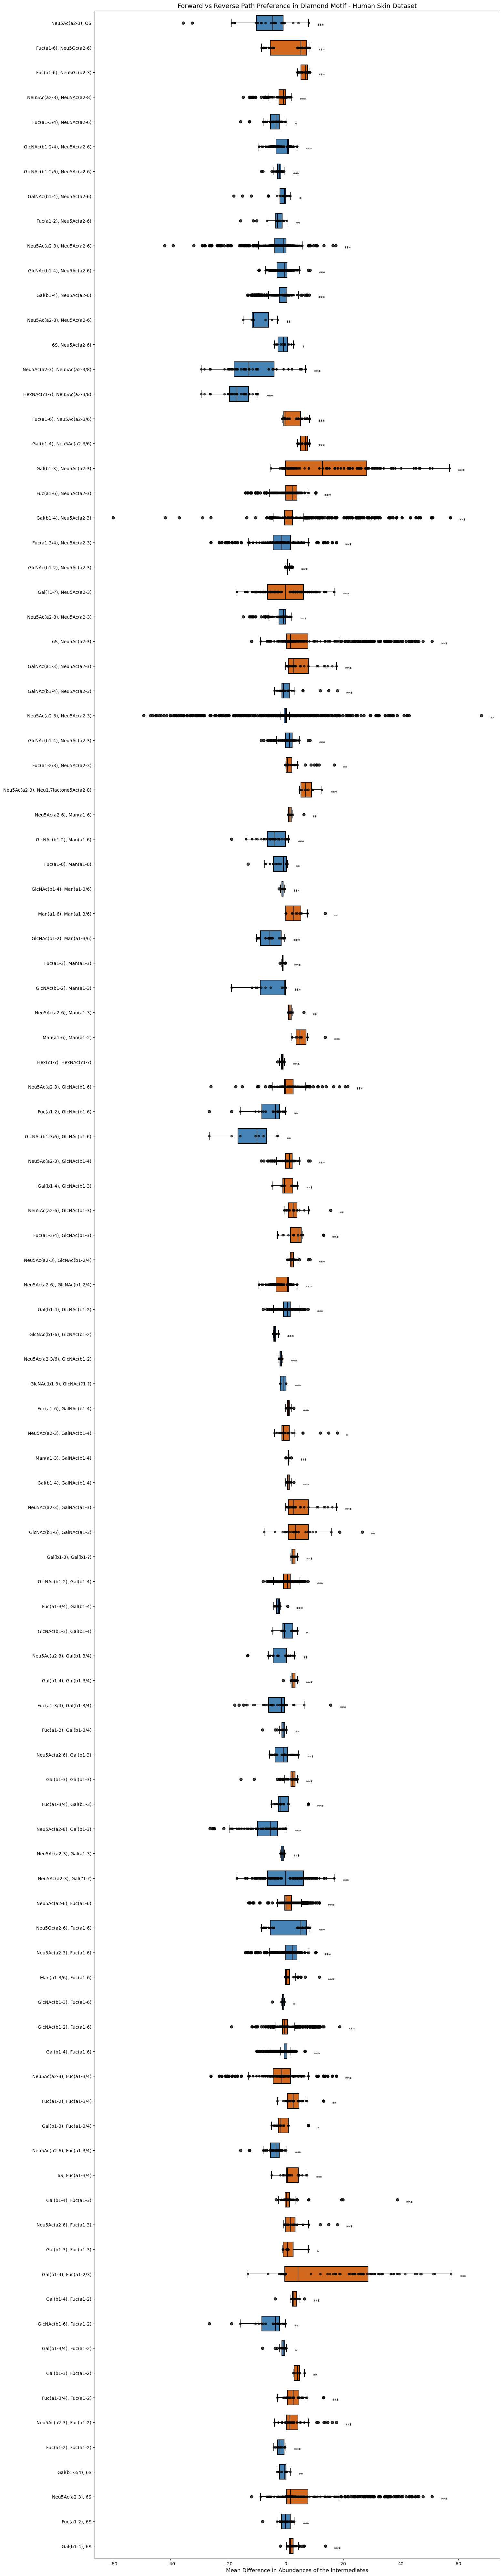

In [23]:
# Define color map for reaction direction
color_map = {
    'forward': '#4682B4',        # Steel Blue (forward)
    'reverse': '#D2691E'         # Chocolate (reverse)
}

# Define SNFG colors for monosaccharides
snfg_color_map = {
    'Fuc': '#FF0000',            # Red (Fucose)
    'Gal': '#FFD700',            # Yellow (Galactose)
    'GlcNAc': '#87CEEB',         # Light Blue (N-Acetylglucosamine)
    'Neu5Ac': '#8A2BE2',         # Purple (N-Acetylneuraminic acid)
    'GalNAc': '#FFD700',         # yellow (N-Acetylgalactosamine)
    'Man': '#32CD32',            # Green (Mannose)
    'Glc': '#0000FF'             # Blue (Glucose)
}

# Define short labels for significance levels
short_significance_labels = {
    'n.s., not significant': 'n.s.',
    '* p < 0.05': '*',
    '** p < 0.01': '**',
    '*** p < 0.001': '***'
}

# Filter out rows with insignificant differences and those below mean difference of 1
filtered_results_welch_df = results_welch_df[
    (results_welch_df['Significance'] != 'n.s., not significant') &
    (abs(results_welch_df['Mean Difference (Abundance 1 - Abundance 2)']) >= 1)
]

# Sort data for clean presentation
results_welch_df_sorted = filtered_results_welch_df.sort_values(by='Diff 2', ascending=False)
# Set up figure
plt.figure(figsize=(16, len(results_welch_df_sorted) * 0.8))
plt.rcParams['font.family'] = 'DejaVu Sans'

# Collect data for box plot and overlay distribution
box_plot_data = []
scatter_data_x = []
scatter_data_y = []
labels = []
colors = []
for i, (index, row) in enumerate(results_welch_df_sorted.iterrows()):
    diff1 = row['Diff 1']
    diff2 = row['Diff 2']
    addition_label = f"{diff1}, {diff2}"
    color = color_map.get(row['Reaction Preference'], color_map['forward'])

    # Add data for box plot from the original df_combined DataFrame
    combined_group = df_combined_all_datasets[(
        (df_combined_all_datasets['Diff 1'] == diff1) & (df_combined_all_datasets['Diff 2'] == diff2)) |
        ((df_combined_all_datasets['Diff 1'] == diff2) & (df_combined_all_datasets['Diff 2'] == diff1))
    ]
    abundance_data = combined_group['Abundance 1'].values - combined_group['Abundance 2'].values
    abundance_data = abundance_data[~np.isnan(abundance_data)]
    box_plot_data.append(abundance_data)
    labels.append(addition_label)
    colors.append(color)

    # Collect data points for overlay
    scatter_data_x.extend(abundance_data)
    scatter_data_y.extend([i + 1] * len(abundance_data))

# Create box plot for combined abundance data
box = plt.boxplot(box_plot_data, positions=np.arange(1, len(box_plot_data) + 1), vert=False, patch_artist=True, widths=0.6)

# Customize the boxes
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Customize the whiskers, caps, and medians
for whisker in box['whiskers']:
    whisker.set(color='black', linewidth=1.5)
for cap in box['caps']:
    cap.set(color='black', linewidth=1.5)
for median in box['medians']:
    median.set(color='black', linewidth=1.5)

# Overlay data distribution as scatter points
plt.scatter(scatter_data_x, scatter_data_y, color='black', alpha=0.7, s=20, zorder=3)

# Add significance indicators above each box plot
for i, (index, row) in enumerate(results_welch_df_sorted.iterrows()):
    significance_label = short_significance_labels.get(row['Significance'], '')
    if significance_label:
        plt.text(np.max(box_plot_data[i]) + 3, i + 1.1, significance_label, ha='left', va='center', fontsize=10)

# Customize plot appearance
plt.xlabel('Mean Difference in Abundances of the Intermediates', fontsize=12)
plt.title('Forward vs Reverse Path Preference in Diamond Motif - Human Skin Dataset', fontsize=14)
plt.xticks(fontsize=10)
plt.gca().invert_yaxis()

# Customize y-tick labels without SNFG color coding
plt.yticks(np.arange(1, len(labels) + 1), labels, fontsize=10)

plt.tight_layout(rect=[0.02, 0, 1, 0.97])
plt.show()
